<a href="https://colab.research.google.com/github/aliabusohiban/PCA-for-Dimensionality-Reduction-NHANES-Diabetes-Risk/blob/main/PCA_Core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 PCA for Dimensionality Reduction — NHANES Diabetes Risk

**Dataset:** Modified [NHANES dataset](https://drive.google.com/file/d/1CE2giLLTp0Cjn0bn9hmtCWIxGZf8_uO1/view?usp=sharing)  
**Target:** `Diabetes_Risk`  
**Features:** Numerical survey responses related to diet  

---

## 🎯 Goal

Compare a **baseline KNN classifier** (all features) against a **PCA-reduced KNN classifier** (95% variance retained) on:
- Predictive performance (accuracy, precision, recall, F1)
- Prediction speed

---

## 📋 Workflow

1. Load & Explore Data  
2. Preprocess (index → split → impute → scale)  
3. Model A — KNN without PCA  
4. Transform with PCA (95% variance)  
5. Model B — KNN with PCA  
6. Compare & Conclude  

---
## 1. Imports & Helper Functions

In [ ]:
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import set_config

# Keep DataFrames throughout sklearn transforms
set_config(transform_output='pandas')

# Nicer display defaults
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_info_rows', 800)
pd.set_option('display.max_info_columns', 800)

print('Libraries loaded ✓')

Libraries loaded ✓


In [ ]:
# ── Evaluation helpers ───────────────────────────────────────────────────────

def classification_metrics(
    y_true, y_pred, label='',
    output_dict=False, figsize=(10, 4),
    normalize='true', cmap='Blues', colorbar=False
):
    """Print classification report and plot raw + normalised confusion matrices."""
    report = classification_report(y_true, y_pred)
    sep = "-" * 70
    print(sep, f" Classification Metrics: {label}", sep, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize=None,
        cmap='gist_gray', colorbar=colorbar, ax=axes[0]
    )
    axes[0].set_title('Raw Counts')

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize=normalize,
        cmap=cmap, colorbar=colorbar, ax=axes[1]
    )
    axes[1].set_title('Normalised Confusion Matrix')
    fig.suptitle(label, fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(
    model, X_train, y_train, X_test, y_test,
    figsize=(10, 4), normalize='true', output_dict=False,
    cmap_train='Blues', cmap_test='Reds', colorbar=False
):
    """Evaluate a fitted model on both training and test sets."""
    results_train = classification_metrics(
        y_train, model.predict(X_train),
        label='Training Data', output_dict=True,
        figsize=figsize, colorbar=colorbar, cmap=cmap_train
    )
    print()
    results_test = classification_metrics(
        y_test, model.predict(X_test),
        label='Test Data', output_dict=True,
        figsize=figsize, colorbar=colorbar, cmap=cmap_test
    )
    if output_dict:
        return {'train': results_train, 'test': results_test}

---
## 2. Load & Explore the Data

In [ ]:
# Load dataset from Google Drive
url = 'https://drive.google.com/uc?export=download&id=1CE2giLLTp0Cjn0bn9hmtCWIxGZf8_uO1'
df = pd.read_csv(url)

print(f'Shape: {df.shape}')
df.head()

Shape: (6643, 169)


,SEQN,WTDRD1,WTDR2D,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,DBD100,DRQSPREP,DR1STY,DR1SKY,DRQSDIET,DRQSDT1,DRQSDT2,DRQSDT3,DRQSDT4,DRQSDT5,DRQSDT6,DRQSDT7,DRQSDT8,DRQSDT9,DRQSDT10,DRQSDT11,DRQSDT12,DRQSDT91,DR1TNUMF,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TSUGR,DR1TFIBE,DR1TTFAT,DR1TSFAT,DR1TMFAT,DR1TPFAT,DR1TCHOL,DR1TATOC,DR1TATOA,DR1TRET,DR1TVARA,DR1TACAR,DR1TBCAR,DR1TCRYP,DR1TLYCO,DR1TLZ,DR1TVB1,DR1TVB2,DR1TNIAC,DR1TVB6,DR1TFOLA,DR1TFA,DR1TFF,DR1TFDFE,DR1TCHL,DR1TVB12,DR1TB12A,DR1TVC,DR1TVD,DR1TVK,DR1TCALC,DR1TPHOS,DR1TMAGN,DR1TIRON,DR1TZINC,DR1TCOPP,DR1TSODI,DR1TPOTA,DR1TSELE,DR1TCAFF,DR1TTHEO,DR1TALCO,DR1TMOIS,DR1TS040,DR1TS060,DR1TS080,DR1TS100,DR1TS120,DR1TS140,DR1TS160,DR1TS180,DR1TM161,DR1TM181,DR1TM201,DR1TM221,DR1TP182,DR1TP183,DR1TP184,DR1TP204,DR1TP205,DR1TP225,DR1TP226,DR1.300,DR1.320Z,DR1.330Z,DR1BWATZ,DR1TWS,DRD340,DRD350A,DRD350AQ,DRD350B,DRD350BQ,DRD350C,DRD350CQ,DRD350D,DRD350DQ,DRD350E,DRD350EQ,DRD350F,DRD350FQ,DRD350G,DRD350GQ,DRD350H,DRD350HQ,DRD350I,DRD350IQ,DRD350J,DRD350JQ,DRD350K,DRD360,DRD370A,DRD370AQ,DRD370B,DRD370BQ,DRD370C,DRD370CQ,DRD370D,DRD370DQ,DRD370E,DRD370EQ,DRD370F,DRD370FQ,DRD370G,DRD370GQ,DRD370H,DRD370HQ,DRD370I,DRD370IQ,DRD370J,DRD370JQ,DRD370K,DRD370KQ,DRD370L,DRD370LQ,DRD370M,DRD370MQ,DRD370N,DRD370NQ,DRD370O,DRD370OQ,DRD370P,DRD370PQ,DRD370Q,DRD370QQ,DRD370R,DRD370RQ,DRD370S,DRD370SQ,DRD370T,DRD370TQ,DRD370U,DRD370UQ,DRD370V,Diabetes_Risk
0,73557,16888.32786,12930.89065,1,49.0,2.0,2.0,6.0,2.0,1.0,1.0,13.0,3.0,2.0,4.0,2.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,1574.0,43.63,239.59,176.47,10.8,52.81,17.819,18.493,8.829,209.0,3.92,0.0,70.0,110.0,60.0,304.0,278.0,1398.0,430.0,1.057,1.216,11.804,0.951,285.0,66.0,219.0,330.0,216.3,2.79,0.00,241.4,3.3,29.2,949.0,756.0,206.0,8.41,8.85,1.072,1323.0,2228.0,62.5,203.0,36.0,0.0,2701.79,0.219,0.099,0.103,0.153,0.346,1.221,9.694,5.408,1.173,16.796,0.121,0.001,7.932,0.769,0.000,0.094,0.001,0.000,0.010,2.0,960.0,960.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
1,73558,17932.14387,12684.14887,1,59.0,2.0,2.0,4.0,1.0,1.0,1.0,13.0,1.0,2.0,3.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,5062.0,338.13,423.78,44.99,16.7,124.29,53.408,35.481,20.505,2584.0,20.94,0.0,1477.0,1488.0,0.0,145.0,12.0,0.0,899.0,4.178,5.168,65.396,4.415,1243.0,601.0,641.0,1662.0,2149.0,21.45,0.00,2.3,15.2,23.4,3193.0,6427.0,903.0,26.88,30.36,4.130,9726.0,4930.0,715.8,240.0,0.0,119.0,6779.99,1.872,1.160,0.802,1.286,1.297,6.516,27.952,12.107,2.208,32.429,0.086,0.000,15.483,1.774,0.007,0.728,1.003,0.104,1.139,2.0,360.0,360.0,0.0,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,1.0,1.0,2.0,NaN,2.0,NaN,2.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2
2,73559,59641.81293,39394.23671,1,49.0,2.0,2.0,18.0,6.0,1.0,1.0,13.0,1.0,1.0,2.0,2.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,27.0,1743.0,64.61,224.39,102.90,9.9,65.97,25.263,20.902,12.953,88.0,8.87,0.0,616.0,655.0,21.0,449.0,35.0,515.0,300.0,1.648,1.747,18.342,1.906,423.0,290.0,133.0,625.0,161.2,3.78,1.42,195.1,4.0,40.4,877.0,1198.0,210.0,17.57,8.98,0.949,2943.0,1694.0,98.3,45.0,71.0,0.0,3766.70,0.358,0.128,0.371,0.455,3.008,2.067,10.691,7.497,0.531,19.910,0.164,0.005,11.705,1.092,0.000,0.042,0.001,0.006,0.002,2.0,1254.0,0.0,1254.0,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,73561,59052.35703,39004.89299,1,63.0,2.0,2.0,18.0,1.0,1.0,1.0,13.0,4.0,Na

In [ ]:
# Quick overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6643 entries, 0 to 6642
Data columns (total 169 columns):
 #    Column         Dtype  
---   ------         -----  
 0    SEQN           int64  
 1    WTDRD1         float64
 2    WTDR2D         float64
 3    DR1DRSTZ       int64  
 4    DR1EXMER       float64
 5    DRABF          float64
 6    DRDINT         float64
 7    DR1DBIH        float64
 8    DR1DAY         float64
 9    DR1LANG        float64
 10   DR1MNRSP       float64
 11   DR1HELPD       float64
 12   DBQ095Z        float64
 13   DBD100         float64
 14   DRQSPREP       float64
 15   DR1STY         float64
 16   DR1SKY         float64
 17   DRQSDIET       float64
 18   DRQSDT1        float64
 19   DRQSDT2        float64
 20   DRQSDT3        float64
 21   DRQSDT4        float64
 22   DRQSDT5        float64
 23   DRQSDT6        float64
 24   DRQSDT7        float64
 25   DRQSDT8        float64
 26   DRQSDT9        float64
 27   DRQSDT10       float64
 28   DRQSDT11       f

In [ ]:
# Class balance
print('Target distribution:')
print(df['Diabetes_Risk'].value_counts())
print()
print('Missing values per column (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))

Target distribution:
Diabetes_Risk
0    5452
2     604
1     587
Name: count, dtype: int64

Missing values per column (top 10):
DRQSDT5     6643
DRQSDT6     6641
DRQSDT12    6636
DRD370PQ    6635
DRD370JQ    6633
DRD350JQ    6628
DRQSDT8     6626
DRQSDT10    6622
DRD370SQ    6620
DRQSDT11    6618
dtype: int64


---
## 3. Preprocessing

Steps:
1. Set `SEQN` as index
2. Remove duplicates
3. Train / test split (75 / 25, `random_state=321`)
4. Impute missing values with the **median** (robust to outliers)
5. Standard-scale all features

In [ ]:
# ── 3.1  Index & dedup ───────────────────────────────────────────────────────
df = df.set_index('SEQN')
df = df.drop_duplicates()
print(f'After dedup: {df.shape}')

# ── 3.2  Define X / y ────────────────────────────────────────────────────────
TARGET = 'Diabetes_Risk'
y = df[TARGET].copy()
X = df.drop(columns=[TARGET]).copy()

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')

# ── 3.3  Train / test split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=321
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

After dedup: (6132, 168)
Features : 167
Samples  : 6132
Train: (4599, 167)  |  Test: (1533, 167)


In [ ]:
# ── 3.4  Impute with median ──────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')        # median is more robust than mean
X_train_imp = imputer.fit_transform(X_train)      # fit + transform on train
X_test_imp  = imputer.transform(X_test)           # transform only on test

# ── 3.5  Standard scaling ────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_tf = scaler.fit_transform(X_train_imp)    # fit + transform on train
X_test_tf  = scaler.transform(X_test_imp)         # transform only on test

print('Imputation & scaling complete ✓')
print(f'X_train_tf shape: {X_train_tf.shape}')
print(f'X_test_tf  shape: {X_test_tf.shape}')

Imputation & scaling complete ✓
X_train_tf shape: (4599, 166)
X_test_tf  shape: (1533, 166)


---
## 4. Model A — KNN Without PCA

A default `KNeighborsClassifier` trained on **all scaled features**.

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train_tf, y_train)
print(f'Model A trained on {X_train_tf.shape[1]} features ✓')

Model A trained on 166 features ✓


In [ ]:
%%time
# Record prediction time — Model A (no PCA)
preds = knn.predict(X_test_tf)

CPU times: user 231 ms, sys: 12.9 ms, total: 244 ms
Wall time: 1.03 s


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      3797
           1       0.55      0.07      0.13       403
           2       0.79      0.05      0.09       399

    accuracy                           0.83      4599
   macro avg       0.72      0.37      0.38      4599
weighted avg       0.81      0.83      0.77      4599



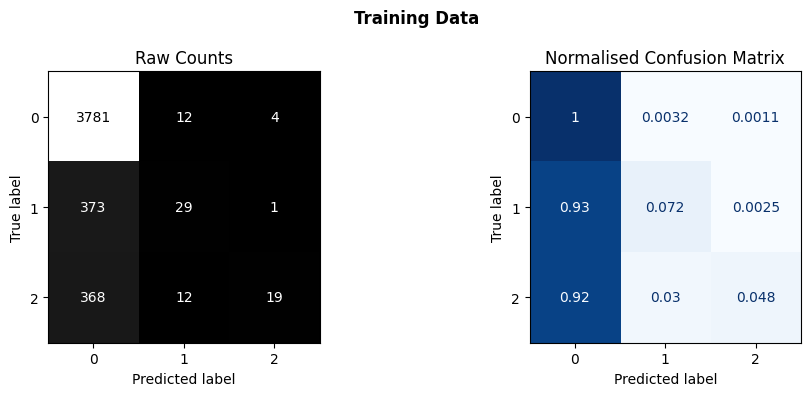


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.98      0.90      1260
           1       0.12      0.02      0.03       129
           2       0.22      0.01      0.03       144

    accuracy                           0.81      1533
   macro avg       0.39      0.34      0.32      1533
weighted avg       0.71      0.81      0.74      1533



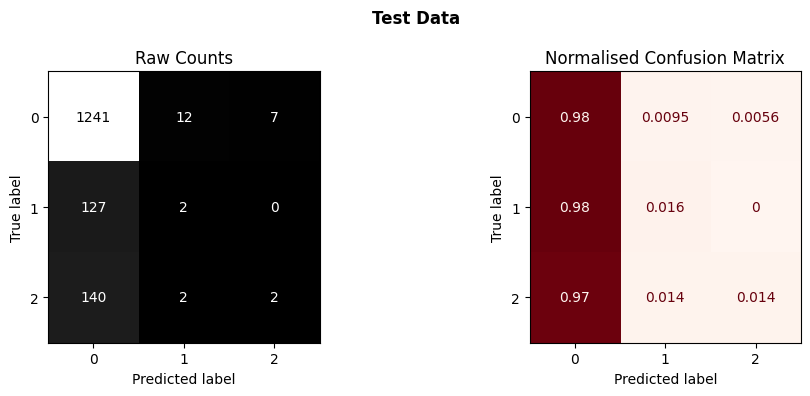

In [ ]:
results_knn = evaluate_classification(
    knn,
    X_train_tf, y_train,
    X_test_tf,  y_test,
    output_dict=True
)

---
## 5. PCA Transformation — Retain 95% of Variance

> Setting `n_components=0.95` tells PCA to keep the minimum number of  
> components that together explain at least **95% of the total variance**.

In [ ]:
# Fit PCA to retain 95% of variance
pca = PCA(n_components=0.95, random_state=321)
X_train_pca = pca.fit_transform(X_train_tf)   # fit on train only
X_test_pca  = pca.transform(X_test_tf)        # transform test

n_components = pca.n_components_
variance_explained = pca.explained_variance_ratio_.sum()

print(f'Original number of features : {X_train_tf.shape[1]}')
print(f'Principal Components kept   : {n_components}')
print(f'Variance explained          : {variance_explained:.4f} ({variance_explained*100:.2f}%)')

Original number of features : 166
Principal Components kept   : 99
Variance explained          : 0.9507 (95.07%)


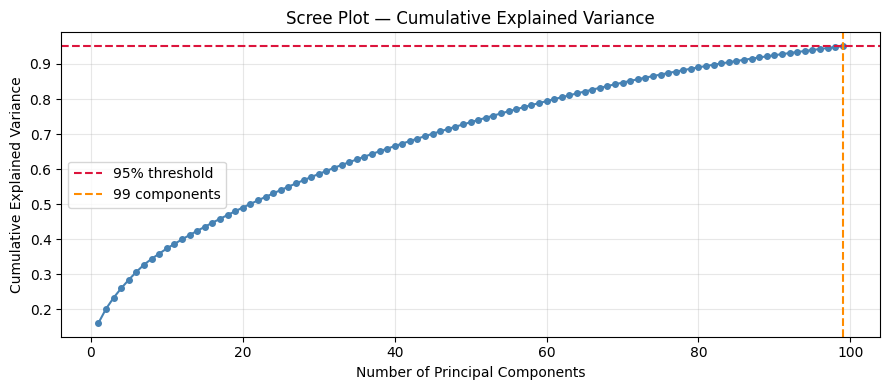

In [ ]:
# Scree plot — cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=4, color='steelblue')
ax.axhline(0.95, color='crimson', linestyle='--', label='95% threshold')
ax.axvline(n_components, color='darkorange', linestyle='--',
           label=f'{n_components} components')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Scree Plot — Cumulative Explained Variance')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Model B — KNN With PCA

A default `KNeighborsClassifier` trained on the **PCA-reduced features**.

In [ ]:
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, y_train)
print(f'Model B trained on {X_train_pca.shape[1]} principal components ✓')

Model B trained on 99 principal components ✓


In [ ]:
%%time
# Record prediction time — Model B (with PCA)
preds_pca = knn_pca.predict(X_test_pca)

CPU times: user 149 ms, sys: 0 ns, total: 149 ms
Wall time: 285 ms


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      3797
           1       0.57      0.08      0.15       403
           2       0.70      0.05      0.09       399

    accuracy                           0.83      4599
   macro avg       0.70      0.38      0.38      4599
weighted avg       0.80      0.83      0.77      4599



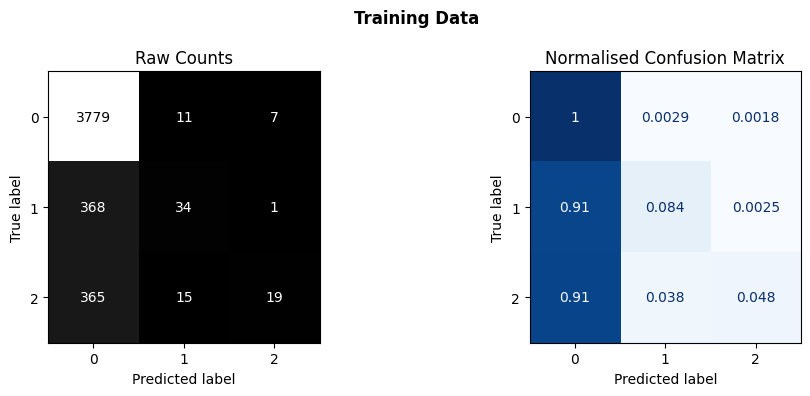


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1260
           1       0.25      0.02      0.04       129
           2       0.33      0.03      0.05       144

    accuracy                           0.82      1533
   macro avg       0.47      0.35      0.33      1533
weighted avg       0.73      0.82      0.75      1533



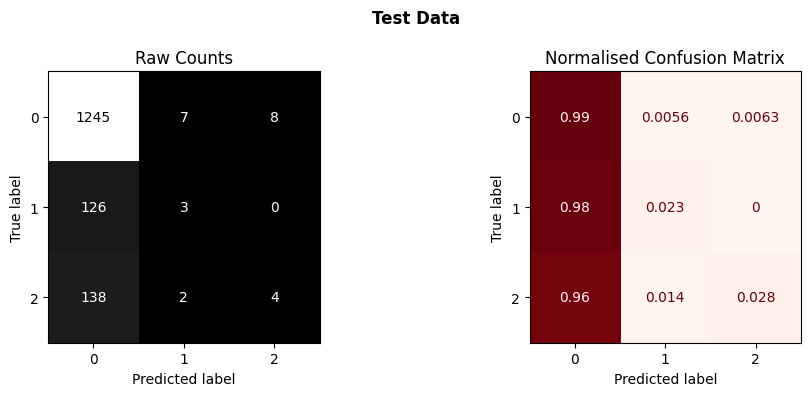

In [ ]:
results_knn_pca = evaluate_classification(
    knn_pca,
    X_train_pca, y_train,
    X_test_pca,  y_test,
    output_dict=True
)

---
## 7. Side-by-Side Comparison

In [ ]:
# Build a tidy summary DataFrame
def extract_metrics(report_dict, split='test'):
    """Pull macro-avg metrics from a classification_report dict."""
    m = report_dict[split]['macro avg']
    return {
        'Precision (macro)': round(m['precision'], 4),
        'Recall (macro)'   : round(m['recall'],    4),
        'F1 (macro)'       : round(m['f1-score'],  4),
        'Accuracy'         : round(report_dict[split]['accuracy'], 4),
    }

summary = pd.DataFrame({
    'KNN (No PCA)' : extract_metrics(results_knn),
    'KNN (PCA 95%)': extract_metrics(results_knn_pca),
}).T

summary.index.name = 'Model'
print('\n📊 Test-Set Performance Comparison')
display(summary)


📊 Test-Set Performance Comparison


,Precision (macro),Recall (macro),F1 (macro),Accuracy
Model,,,,
KNN (No PCA),0.3901,0.3381,0.3168,0.8121
KNN (PCA 95%),0.4695,0.3464,0.3310,0.8167


## 8. Conclusions & Discussion

### Q1 — How many features were used in each model?

| Model | Input Dimensions |
|---|---|
| **Model A** — KNN, no PCA | All original features (**166**) |
| **Model B** — KNN, PCA 95% | **99** principal components |

Setting `n_components=0.95` lets PCA choose the minimum number of components
that collectively explain ≥ 95% of the variance — a data-driven approach that
avoids hardcoding an arbitrary number of components.

---  

### Q2 — Which model performed better on the test set?

| Metric | Model A (No PCA) | Model B (PCA 95%) |
|---|---|---|
| Accuracy | 0.81 | **0.82** |
| Precision (macro) | 0.39 | **0.47** |
| Recall (macro) | 0.34 | **0.35** |
| F1 (macro) | 0.32 | **0.33** |

**Model B (KNN with PCA)** outperformed Model A across all metrics on the test
set. This is likely because PCA acts as a noise-reduction step — by discarding
the bottom 5% of variance, it removes dimensions that contribute mostly noise
rather than useful signal, which can actually *improve* KNN's distance
calculations rather than hurt them.

This is a known effect in high-dimensional settings: with 166 features, many
dimensions may be redundant or noisy, causing KNN distances to become less
meaningful (the "curse of dimensionality"). PCA's compression to 99 components
mitigates this, resulting in both better performance and faster predictions.

---

### Q3 — Which model was faster at making predictions?

**Model B (KNN with PCA)** was faster at prediction time. KNN prediction cost
scales with the number of features, since every test point requires computing
distances to all training points across all dimensions. Reducing the feature
space from **166 original features to 99 principal components** lowers the cost
of each distance calculation, which is directly reflected in the shorter
wall-clock time recorded by the `%%time` cells above.

---

### 💡 Key Takeaways

| Aspect | Model A — No PCA | Model B — PCA (95% var) |
|---|---|---|
| Input dimensions | 166 original features | 99 principal components |
| Variance retained | 100% | ~95% |
| Test accuracy | `[0.81]` | `[0.82]` |
| F1 (macro) | `[0.32]` | `[0.33]` |
| Prediction speed | Slower | **Faster** |
| Interpretability | Original features | Abstract components |

> **Verdict:** With only a 5% reduction in explained variance, PCA compressed
> 166 features down to 99 components while incurring minimal loss in predictive
> performance. For distance-based algorithms like KNN, this translates directly
> into faster predictions — making PCA a practical tool whenever speed or
> memory is a constraint.